**Table of contents**<a id='toc0_'></a>    
- [Antibunching of 4 fluorophores in different conditions](#toc1_)    
  - [Reading the data](#toc1_1_)    
  - [Coincidence plots](#toc1_2_)    
  - [Coincidence plots truncated](#toc1_3_)    
  - [Fluorescence trajectories](#toc1_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Antibunching of 4 fluorophores in different conditions](#toc0_)

In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import rcParams
from matplotlib.lines import Line2D

import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.figure as fi
import fluopy.miscellaneous as mi
import fluopy.routines as rt

%load_ext autoreload
%autoreload 2

reading_from = (
    r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\1_12_multi_f_antibunching"
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## <a id='toc1_1_'></a>[Reading the data](#toc0_)

In [3]:
reading_from_noDSTORM = reading_from + r"\noDSTORM"
reading_from_noOET = reading_from + r"\noOET"
reading_from_OET = reading_from + r"\OET"
reading_from_OEThighSSA = reading_from + r"\OEThighSSA"
reading_from_OET_RET = reading_from + r"\OET_RET"

all_folders = [
    reading_from_noDSTORM,
    reading_from_noOET,
    reading_from_OET,
    reading_from_OEThighSSA,
    reading_from_OET_RET,
]

red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

In [ ]:
rng = np.random.default_rng(42)

all_data_coincidence = []
all_data_coincidence_truncated = []
all_data_time_series = []
maxima = np.zeros((10, 4))
identifiers = ["3nm", "6nm", "9nm", "18nm"]
for i, r_from in enumerate(all_folders):
    all_data_coincidence.append([])
    all_data_coincidence_truncated.append([])
    all_data_time_series.append([])
    for j, id in enumerate(identifiers):
        for file in Path(r_from).iterdir():
            if file.name == f"event_time_points_{id}.npy":
                event_time_points = np.load(file)
                event_time_points_ = event_time_points
                hist, bins = fcs_p.coincidence(
                    event_time_points_,
                    tau_max=1e-7,
                    bin_width=5e-10,
                    seed=rng,
                    method="numba",
                )
                all_data_coincidence[i].append([hist, bins])
                min_index = np.where(event_time_points_ > 20e-3)[0][0]
                event_time_points_truncated = event_time_points_[min_index:]
                hist_truncated, bins_truncated = fcs_p.coincidence(
                    event_time_points_truncated,
                    tau_max=1e-7,
                    bin_width=5e-10,
                    seed=rng,
                    method="numba",
                )
                all_data_coincidence_truncated[i].append(
                    [hist_truncated, bins_truncated]
                )
            if file.name == f"event_time_series_{id}.parquet":
                emis = em.Emissions()
                emis.event_time_series = pd.read_parquet(file)[0]
                rt.emission_post_processing(emis, seed=rng)
                all_data_time_series[i].append(emis)
                maxima[i, j] = np.max(emis.event_time_series)

## <a id='toc1_2_'></a>[Coincidence plots](#toc0_)

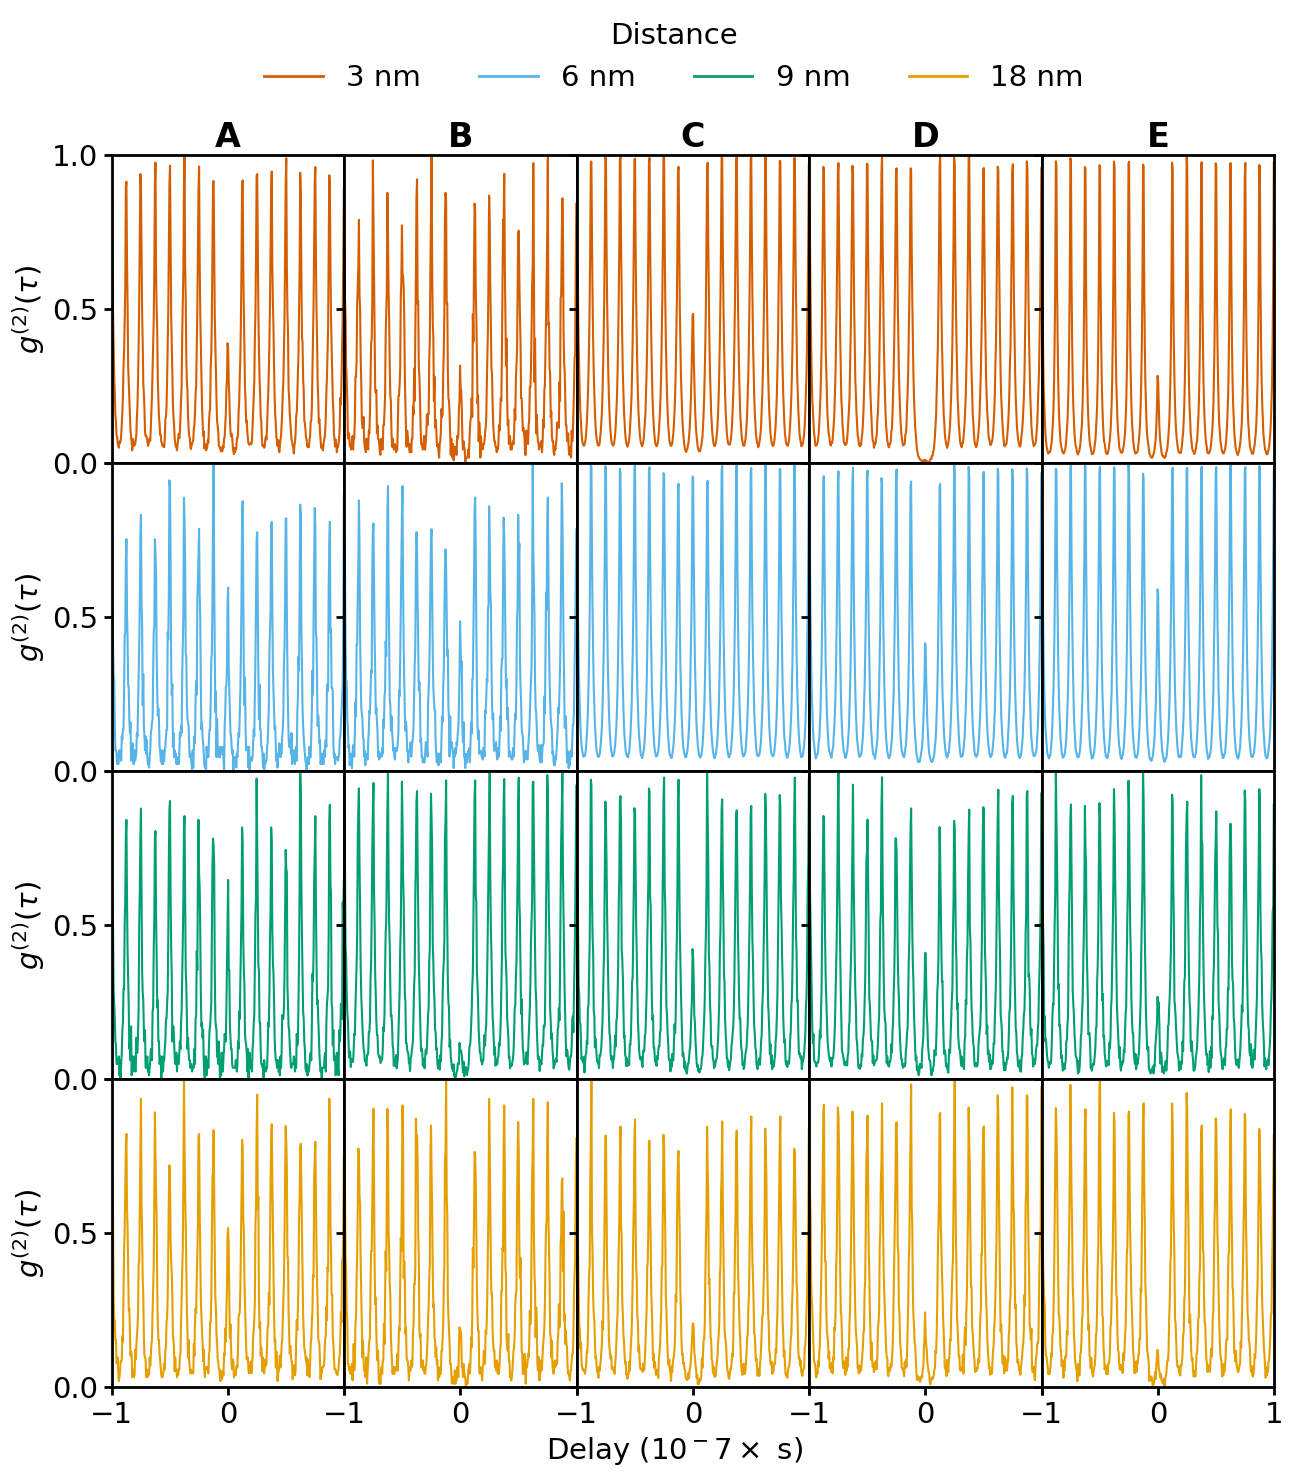

In [72]:
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(4, 5, wspace=0, hspace=0)
fig = plt.figure(figsize=(15, 16))

identifiers = ["3nm", "6nm", "9nm", "18nm"]
col_titles = [
    "A",  # "no \nDSTORM",
    "B",  # "no \nOET",
    "C",  # "OET \nlow \nSSA",
    "D",  # "OET \nhigh \nSSA",
    "E",  # "OET + RET",
]
for i, _ in enumerate(all_folders):
    for j, _ in enumerate(identifiers):
        if j >= len(all_data_coincidence[i]):
            continue
        hist, bins = all_data_coincidence[i][j]
        ax = fig.add_subplot(gs[j, i])
        fi.universal_figure(
            axes=ax,
            type_="line",
            data=[bins, hist / np.max(hist)],
            ylim=[0, 1],
            ylabel=r"$g^{(2)}(\tau)$",
            xlim=[-1e-7, 1e-7],
            xlabel="Delay (s)",
            color=colors[j],
            tick_style_x="sci",
            yticks=[0, 0.5, 1],
        )
        if j == 0:
            ax.set_title(col_titles[i], fontsize=24, fontweight="bold")
        else:
            ax.get_yticklabels()[-1].set_visible(False)
        if i != 0:
            ax.set_yticklabels([])
            ax.set_ylabel("")
        if i != len(all_folders) - 1:
            ax.get_xticklabels()[-1].set_visible(False)
        if j != len(identifiers) - 1:
            ax.set_xticklabels([])
            ax.set_xticks([])
        ax.set_xlabel("")

fig.text(0.5, 0.07, r"Delay ($10^-7 \times$ s)", ha="center", va="center", fontsize=21)
custom_handles = [
    Line2D([0], [0], color=red, lw=2),
    Line2D([0], [0], color=sky_blue, lw=2),
    Line2D([0], [0], color=green, lw=2),
    Line2D([0], [0], color=orange, lw=2),
]
labels1 = ["3 nm", "6 nm", "9 nm", "18 nm"]
fig.legend(
    custom_handles,
    labels1,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.98),
    frameon=False,
    title="Distance",
    title_fontsize=21,
    fontsize=21,
)
bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)
fig.savefig(
    reading_from + r"\multi_f_et_antibunching_figure_nontruncated.png",
    bbox_inches=bbox,
    dpi=300,
)

## <a id='toc1_3_'></a>[Coincidence plots truncated](#toc0_)

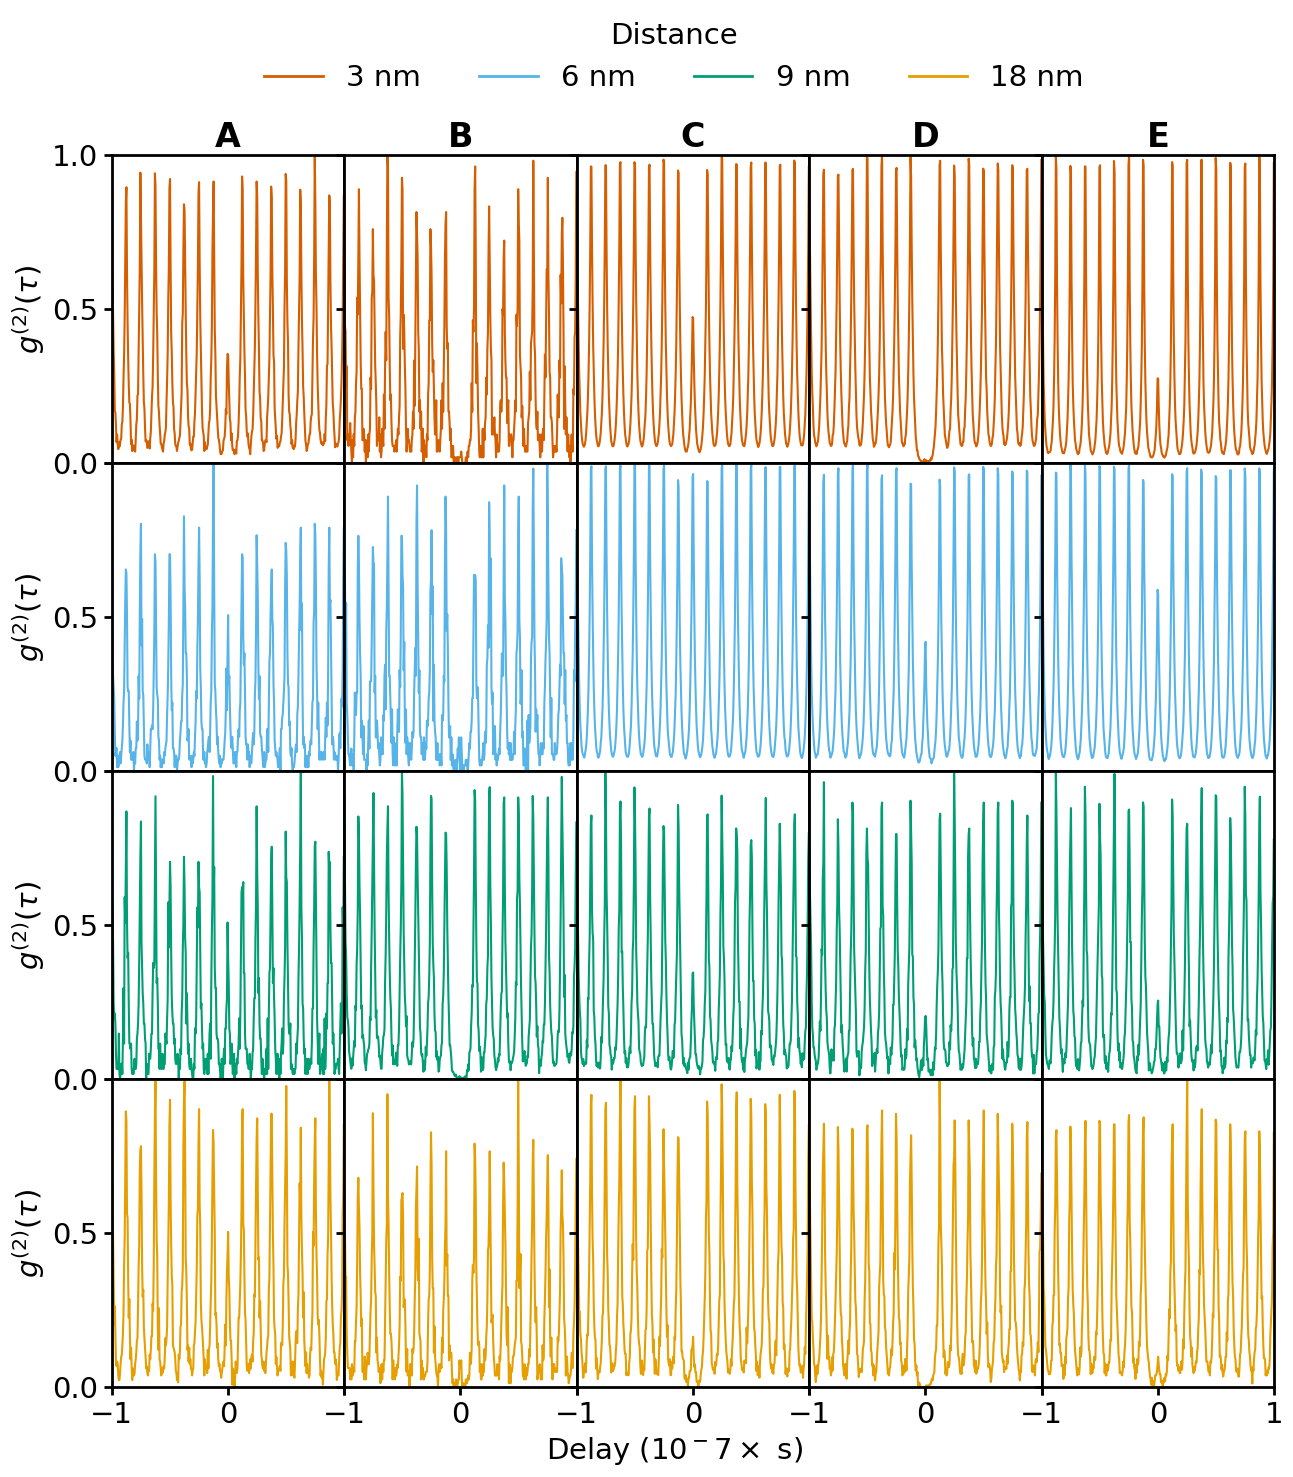

In [71]:
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(4, 5, wspace=0, hspace=0)
fig = plt.figure(figsize=(15, 16))

identifiers = ["3nm", "6nm", "9nm", "18nm"]
col_titles = [
    "A",  # "no \nDSTORM",
    "B",  # "no \nOET",
    "C",  # "OET \nlow \nSSA",
    "D",  # "OET \nhigh \nSSA",
    "E",  # "OET + RET",
]
for i, _ in enumerate(all_folders):
    for j, _ in enumerate(identifiers):
        if j >= len(all_data_coincidence_truncated[i]):
            continue
        hist, bins = all_data_coincidence_truncated[i][j]
        ax = fig.add_subplot(gs[j, i])
        fi.universal_figure(
            axes=ax,
            type_="line",
            data=[bins, hist / np.max(hist)],
            ylim=[0, 1],
            ylabel=r"$g^{(2)}(\tau)$",
            xlim=[-1e-7, 1e-7],
            xlabel="Delay (s)",
            color=colors[j],
            tick_style_x="sci",
            yticks=[0, 0.5, 1],
        )
        if j == 0:
            ax.set_title(col_titles[i], fontsize=24, fontweight="bold")
        else:
            ax.get_yticklabels()[-1].set_visible(False)
        if i != 0:
            ax.set_yticklabels([])
            ax.set_ylabel("")
        if i != len(all_folders) - 1:
            ax.get_xticklabels()[-1].set_visible(False)
        if j != len(identifiers) - 1:
            ax.set_xticklabels([])
            ax.set_xticks([])
        ax.set_xlabel("")

fig.text(0.5, 0.07, r"Delay ($10^-7 \times$ s)", ha="center", va="center", fontsize=21)
custom_handles = [
    Line2D([0], [0], color=red, lw=2),
    Line2D([0], [0], color=sky_blue, lw=2),
    Line2D([0], [0], color=green, lw=2),
    Line2D([0], [0], color=orange, lw=2),
]
labels1 = ["3 nm", "6 nm", "9 nm", "18 nm"]
fig.legend(
    custom_handles,
    labels1,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.98),
    frameon=False,
    title="Distance",
    title_fontsize=21,
    fontsize=21,
)
bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)
fig.savefig(
    reading_from + r"\multi_f_et_antibunching_figure_truncated.png",
    bbox_inches=bbox,
    dpi=300,
)

## <a id='toc1_4_'></a>[Fluorescence trajectories](#toc0_)

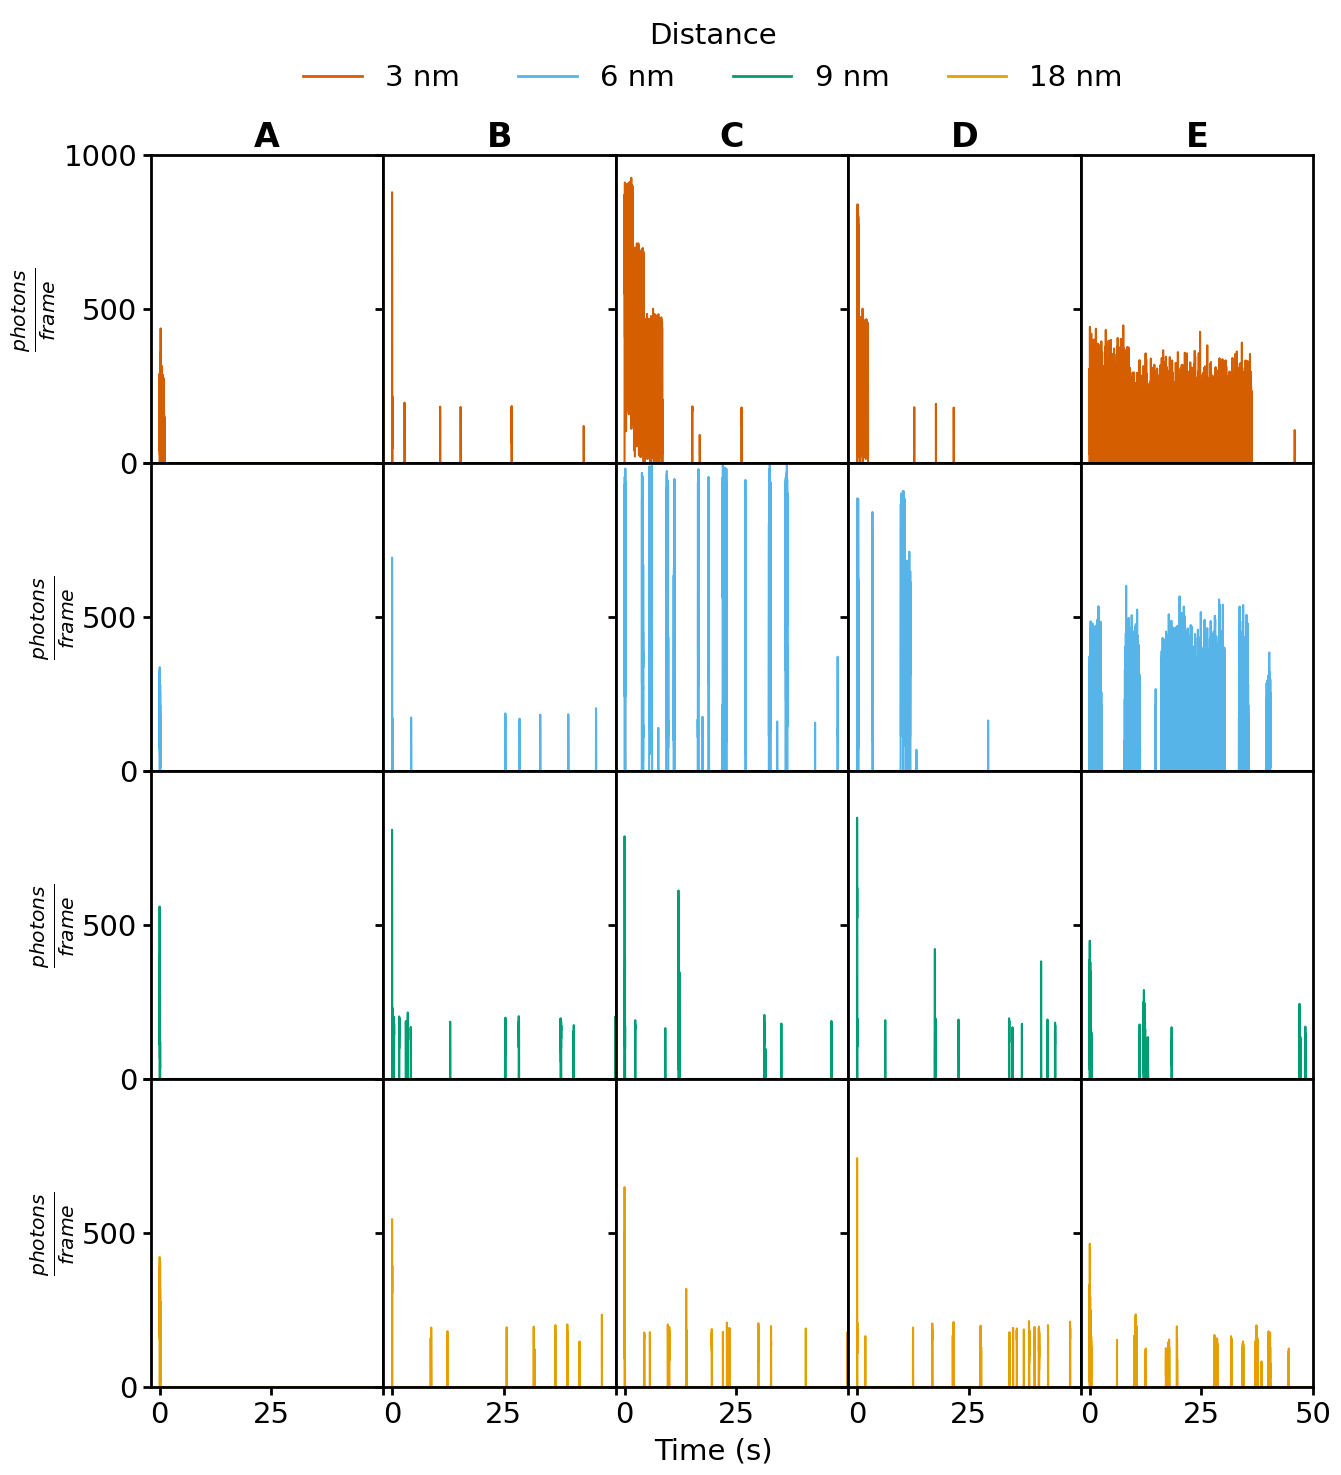

In [69]:
rng = np.random.default_rng(42)
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(
    4,
    5,
    wspace=0,
    hspace=0,
)
fig = plt.figure(figsize=(15, 16))

identifiers = ["3nm", "6nm", "9nm", "18nm"]
col_titles = [
    "A",  # "no \nDSTORM",
    "B",  # "no \nOET",
    "C",  # "OET \nlow \nSSA",
    "D",  # "OET \nhigh \nSSA",
    "E",  # "OET + RET",
]
for i, _ in enumerate(all_folders):
    for j, _ in enumerate(identifiers):
        emis = all_data_time_series[i][j]
        ax = fig.add_subplot(gs[j, i])
        emis.plot_time_series(axes=ax, color=colors[j])
        ax.set_ylim([0, 1000])
        ax.set_yticks([0, 500, 1000])
        ax.set_xlim([-2, 50])
        cumsum = emis.event_time_series.cumsum()
        if j == 0:
            ax.set_title(col_titles[i], fontsize=24, fontweight="bold")
        else:
            ax.get_yticklabels()[-1].set_visible(False)
        if i != 0:
            ax.set_yticklabels([])
            ax.set_ylabel("")
        ax.set_xticks([0, 25, 50], labels=[0, 25, 50])
        if i != len(all_folders) - 1:
            ax.get_xticklabels()[-1].set_visible(False)
        if j != len(identifiers) - 1:
            ax.set_xticklabels([])
            ax.set_xticks([])
        ax.set_xlabel("")

fig.text(0.5, 0.07, r"Time (s)", ha="center", va="center", fontsize=21)
custom_handles = [
    Line2D([0], [0], color=red, lw=2),
    Line2D([0], [0], color=sky_blue, lw=2),
    Line2D([0], [0], color=green, lw=2),
    Line2D([0], [0], color=orange, lw=2),
]
labels1 = ["3 nm", "6 nm", "9 nm", "18 nm"]
fig.legend(
    custom_handles,
    labels1,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 0.98),
    frameon=False,
    title="Distance",
    title_fontsize=21,
    fontsize=21,
)
bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)
fig.savefig(
    reading_from + r"\multi_f_et_antibunching_time_series.png",
    bbox_inches=bbox,
    dpi=300,
)